<a href="https://colab.research.google.com/github/adryann-olivatti/IC_cozinhas_solidarias/blob/main/notebook_renda_cozinhas_solidarias_corrigido(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Renda por Organização Fornecedora (PAA - Cozinhas Solidárias)

Este notebook responde à seguinte pergunta:
**"Qual é a renda por organização fornecedora, categorizada por tipo?"**

### Fontes de Dados Utilizadas:
1. **Catálogo de Dados (JSON):** [GitHub - TriangulosTecnologia/cozsolidarias](https://github.com/TriangulosTecnologia/cozsolidarias/blob/main/public/dataset_catalogue.json)
2. **Portal de Dados:** [Cozinhas Solidárias - Dados](https://cozsolidarias.triangulos.tech/dados)
3. **Planilha de Dados CONAB:** [Google Sheets - Dados CONAB PAA 2025](https://docs.google.com/spreadsheets/d/1O_mmcnZ2QCBkA6juq_TzKYFv6KDwHsCU/edit)

## 1. Importação de Bibliotecas e Configuração Inicial

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: 'R$ {:,.2f}'.format(x))

## 2. Carregamento dos Dados da CONAB
Baixando diretamente os dados da planilha do Google Sheets com busca automática de aba e cabeçalho.

In [36]:
# ID da planilha pública do Google Sheets
sheet_id = '1O_mmcnZ2QCBkA6juq_TzKYFv6KDwHsCU'
url_export = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=xlsx'

print('Baixando e analisando a planilha da CONAB...')

# 1. Carrega todas as abas do arquivo Excel
xls = pd.ExcelFile(url_export)
print('Abas encontradas:', xls.sheet_names)

# 2. Procura automaticamente a aba e a linha do cabeçalho
df_raw = None

for aba in xls.sheet_names:
    temp = pd.read_excel(xls, sheet_name=aba, header=None)
    for i in range(min(20, len(temp))):
        linha_texto = [str(val).upper() for val in temp.iloc[i].tolist()]
        if any('PROPONENTE' in col or 'CNPJ' in col for col in linha_texto):
            print(f"-> Dados localizados na aba '{aba}', cabeçalho na linha {i + 1}")
            df_raw = pd.read_excel(xls, sheet_name=aba, skiprows=i)
            break
    if df_raw is not None and len(df_raw) > 0:
        break

# Caso não encontre pela busca dinâmica, tenta carregar a primeira aba
if df_raw is None or len(df_raw) == 0:
    df_raw = pd.read_excel(xls, sheet_name=xls.sheet_names[0], skiprows=6)

print(f'Sucesso! {df_raw.shape[0]} linhas e {df_raw.shape[1]} colunas carregadas.')
df_raw.head()

Baixando e analisando a planilha da CONAB...
Abas encontradas: ['DADOS', 'PRODUTOS', 'CONTRATAÇÕES 2025', 'UNIDADES RECEBEDORAS']
-> Dados localizados na aba 'PRODUTOS', cabeçalho na linha 10
Sucesso! 1996 linhas e 20 colunas carregadas.


,ANO ORÇAMENTO,MECANISMO,MECANISMO RESUMO,RECURSO,UF CONAB,REGIÃO,TPAF,IBGE,MUNICÍPIO,NOME PROPONENTE,CNPJ PROPONENTE,TIPO DE ORG,ORG DE MULHERES,PRODUTO,Categoria produto,CLASSIFICAÇÃO,VALOR (R$),QUANTIDADE (KG),ORGÂNICO (SIM),Preço
0,"R$ 2,025.00",MDS,CDS/COZINHAS,COZINHAS,AC,NORTE,AC/2025/02/0208,"R$ 1,200,104.00",BRASILÉIA,COOPERATIVA DE PRODUTORES AGROFLORESTAIS E AGR...,09.197.432/0001-09,AGRICULTOR FAMILIAR,NaN,FEIJAO,GRÃOS E OLEAGINOSAS,NÃO INFORMADO,"R$ 15,000.00","R$ 1,250.00",NaN,R$ 12.00
1,"R$ 2,025.00",MDS,CDS/COZINHAS,COZINHAS,AC,NORTE,AC/2025/02/0210,"R$ 1,200,807.00",PORTO ACRE,"Cooperativa dos Produtores, Extrativistas de A...",18.020.228/0001-09,AGRICULTOR FAMILIAR,NaN,ABOBORA,HORTIGRANJEIROS,NÃO INFORMADO,"R$ 7,500.00","R$ 1,000.00",NaN,R$ 7.50
2,"R$ 2,025.00",MDS,CDS/COZINHAS,COZINHAS,AC,NORTE,AC/2025/02/0210,"R$ 1,200,807.00",PORTO ACRE,"Cooperativa dos Produtores, Extrativistas de A...",18.020.228/0001-09,AGRICULTOR FAMILIAR,NaN,COUVE,HORTIGRANJEIROS,NÃO INFORMADO,"R$ 8,750.00",R$ 350.00,NaN,R$ 25.00
3,"R$ 2,025.00",MDS,CDS/COZINHAS,COZINHAS,AC,NORTE,AC/2025/02/0210,"R$ 1,200,807.00",PORTO ACRE,"Cooperativa dos Produtores, Extrativistas de A...",18.020.228/0001-09,AGRICULTOR FAMILIAR,NaN,FARINHA DE MANDIOCA,PROCESSADOS,NÃO INFORMADO,"R$ 29,250.00","R$ 3,900.00",NaN,R$ 7.50
4,"R$ 2,025.00",MDS,CDS/COZINHAS,COZINHAS,AC,NORTE,AC/2025/02/0210,"R$ 1,200,807.00",PORTO ACRE,"Cooperativa dos Produtores, Extrativistas de A...",18.020.228/0001-09,AGRICULTOR FAMILIAR,NaN,FECULA DE MANDIOCA,PROCESSADOS,NÃO INFORMADO,"R$ 14,960.00","R$ 1,360.00",NaN,R$ 11.00


## 3. Limpeza e Tratamento dos Dados
Selecionamos as colunas relevantes, limpamos os valores monetários e padronizamos os textos.

In [37]:
# Mapeamento com as colunas reais da CONAB
cols_interesse = ['TIPO DE ORG', 'NOME PROPONENTE', 'CNPJ PROPONENTE', 'VALOR (R$)', 'UF CONAB', 'REGIÃO', 'PRODUTO']

# Filtrar apenas as colunas existentes no dataframe lido
cols_presentes = [c for c in cols_interesse if c in df_raw.columns]
df = df_raw[cols_presentes].copy()

# Tratamento da coluna de valor financeiro
def limpar_valor(val):
    if pd.isna(val):
        return 0.0
    if isinstance(val, (int, float)):
        return float(val)
    val_str = str(val).replace('R$', '').replace('.', '').replace(',', '.').strip()
    try:
        return float(val_str)
    except:
        return 0.0

df['VALOR_NUMERICO'] = df['VALOR (R$)'].apply(limpar_valor)

# Padronização de textos
df['TIPO DE ORG'] = df['TIPO DE ORG'].astype(str).str.strip().str.upper()
df['NOME PROPONENTE'] = df['NOME PROPONENTE'].astype(str).str.strip().str.upper()

print(f"{len(df)} registros processados. Valor total acumulado: R$ {df['VALOR_NUMERICO'].sum():,.2f}")
df[['TIPO DE ORG', 'NOME PROPONENTE', 'VALOR (R$)', 'VALOR_NUMERICO']].head()

1996 registros processados. Valor total acumulado: R$ 238,414,952.24


,TIPO DE ORG,NOME PROPONENTE,VALOR (R$),VALOR_NUMERICO
0,AGRICULTOR FAMILIAR,COOPERATIVA DE PRODUTORES AGROFLORESTAIS E AGR...,"R$ 15,000.00","R$ 15,000.00"
1,AGRICULTOR FAMILIAR,"COOPERATIVA DOS PRODUTORES, EXTRATIVISTAS DE A...","R$ 7,500.00","R$ 7,500.00"
2,AGRICULTOR FAMILIAR,"COOPERATIVA DOS PRODUTORES, EXTRATIVISTAS DE A...","R$ 8,750.00","R$ 8,750.00"
3,AGRICULTOR FAMILIAR,"COOPERATIVA DOS PRODUTORES, EXTRATIVISTAS DE A...","R$ 29,250.00","R$ 29,250.00"
4,AGRICULTOR FAMILIAR,"COOPERATIVA DOS PRODUTORES, EXTRATIVISTAS DE A...","R$ 14,960.00","R$ 14,960.00"


## 4. Agrupamento: Calculando a Renda por Organização e Categoria
Agrupamos por `TIPO DE ORG` e `NOME PROPONENTE`, calculando a **Renda Total**, o **Número de Produtos** e o **Valor Médio por Item**.

In [38]:
# Agrupamento por Tipo de Organização e Nome do Proponente
renda_por_organizacao = df.groupby(['TIPO DE ORG', 'NOME PROPONENTE', 'CNPJ PROPONENTE']).agg(
    RENDA_TOTAL=('VALOR_NUMERICO', 'sum'),
    QTD_PRODUTOS_FORNECIDOS=('VALOR_NUMERICO', 'count'),
    VALOR_MEDIO_POR_ITEM=('VALOR_NUMERICO', 'mean')
).reset_index()

# Ordenando por Tipo de Organização e Renda Total Decrescente
renda_por_organizacao = renda_por_organizacao.sort_values(by=['TIPO DE ORG', 'RENDA_TOTAL'], ascending=[True, False])

# Exibindo a tabela consolidada
print("=== RENDA POR ORGANIZAÇÃO FORNECEDORA (CATEGORIZADA POR TIPO) ===")
display(renda_por_organizacao)

=== RENDA POR ORGANIZAÇÃO FORNECEDORA (CATEGORIZADA POR TIPO) ===


,TIPO DE ORG,NOME PROPONENTE,CNPJ PROPONENTE,RENDA_TOTAL,QTD_PRODUTOS_FORNECIDOS,VALOR_MEDIO_POR_ITEM
72,AGRICULTOR FAMILIAR,COOPERATIVA MISTA DE PRODUÇÃO E COMERCIALIZAÇÃ...,07.239.540/0001-71,"R$ 2,995,780.00",2,"R$ 1,497,890.00"
68,AGRICULTOR FAMILIAR,COOPERATIVA DOS SUINOCULTORES DO CAI SUPERIOR,91.360.420/0001-34,"R$ 2,695,789.70",6,"R$ 449,298.28"
47,AGRICULTOR FAMILIAR,COOPERATIVA DE DESENVOLVIMENTO REGIONAL LTDA,07.508.742/0001-71,"R$ 2,059,917.55",14,"R$ 147,136.97"
82,AGRICULTOR FAMILIAR,UNIÃ_X0083_O DAS ASSOCIAÃ_X0087_Ã_X0095_ES E C...,72.223.829/0001-64,"R$ 1,499,999.10",6,"R$ 249,999.85"
37,AGRICULTOR FAMILIAR,COOPERATIVA AGROINDUSTRIAL FRUTOS DA AMAZONIA,43.003.212/0001-35,"R$ 1,374,820.34",7,"R$ 196,402.91"
...,...,...,...,...,...,...
245,POVOS INDÍGENAS,ASSOCIACAO INDIGENA ABANATSA,30.410.972/0001-15,"R$ 165,500.00",1,"R$ 165,500.00"
247,QUILOMBOLA,ASSOCIACAO DA COMUNIDADE TRADICIONAL DOS PESCA...,10.932.537/0001-43,"R$ 405,600.00",1,"R$ 405,600.00"
249,QUILOMBOLA,ASSOCIAÃ_X0083_Â_X0087_Ã_X0083_Â_X0083_O DOS R...,28.594.779/0001-30,"R$ 119,934.25",6,"R$ 19,989.04"
246,QUILOMBOLA,ASSOC. DE MOR. E PROD. RURAIS REMANESCENTE DO...,18.669.021/0001-60,"R$ 100,000.00",6,"R$ 16,666.67"


## 5. Resumo Consolidado por Tipo de Organização
Visão agregada da renda total distribuída por cada categoria/tipo de organização fornecedora.

In [39]:
resumo_tipo = df.groupby('TIPO DE ORG').agg(
    RENDA_TOTAL=('VALOR_NUMERICO', 'sum'),
    QTD_ORGANIZACOES=('NOME PROPONENTE', 'nunique'),
    QTD_TOTAL_ITENS=('VALOR_NUMERICO', 'count')
).reset_index()

# Renda média por organização dentro da categoria
resumo_tipo['RENDA_MEDIA_POR_ORG'] = resumo_tipo['RENDA_TOTAL'] / resumo_tipo['QTD_ORGANIZACOES']
resumo_tipo['PCT_RENDA_TOTAL'] = (resumo_tipo['RENDA_TOTAL'] / resumo_tipo['RENDA_TOTAL'].sum()) * 100

resumo_tipo = resumo_tipo.sort_values(by='RENDA_TOTAL', ascending=False)

print("=== RESUMO TOTAL DE RENDA POR TIPO DE ORGANIZAÇÃO ===")
display(resumo_tipo)

=== RESUMO TOTAL DE RENDA POR TIPO DE ORGANIZAÇÃO ===


,TIPO DE ORG,RENDA_TOTAL,QTD_ORGANIZACOES,QTD_TOTAL_ITENS,RENDA_MEDIA_POR_ORG,PCT_RENDA_TOTAL
6,NAN,"R$ 119,207,476.10",1,1,"R$ 119,207,476.10",R$ 50.00
0,AGRICULTOR FAMILIAR,"R$ 37,564,279.52",83,710,"R$ 452,581.68",R$ 15.76
1,AGRICULTORES FAMILIARES,"R$ 37,454,152.72",81,689,"R$ 462,396.95",R$ 15.71
3,ASSENTADO DA REFORMA AGRÁRIA,"R$ 17,416,129.43",35,228,"R$ 497,603.70",R$ 7.30
4,ASSENTADOS DA REFORMA AGRARIA,"R$ 14,829,144.30",28,173,"R$ 529,612.30",R$ 6.22
8,PESCADORES ARTESANAIS,"R$ 7,330,298.82",8,29,"R$ 916,287.35",R$ 3.07
7,PESCADOR ARTESANAL,"R$ 2,374,303.56",7,40,"R$ 339,186.22",R$ 1.00
2,AGROEXTRATIVISTA,"R$ 788,175.40",1,72,"R$ 788,175.40",R$ 0.33
10,QUILOMBOLA,"R$ 725,524.25",4,31,"R$ 181,381.06",R$ 0.30
5,COMUNIDADE INDÍGENA,"R$ 559,968.14",2,22,"R$ 279,984.07",R$ 0.23


## 6. Visualização Gráfica
Gráfico para ilustrar a distribuição da renda entre os diferentes tipos de organizações fornecedoras.

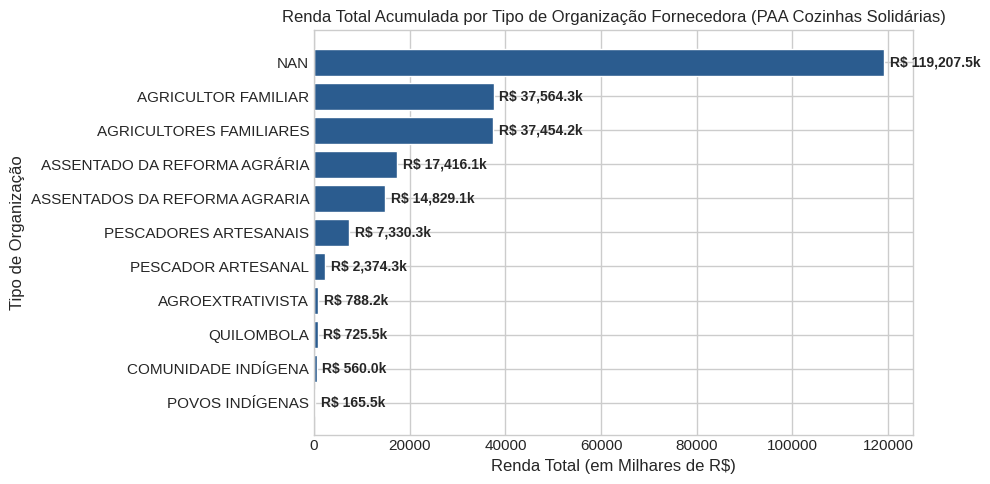

In [40]:
# Gráfico: Renda Total por Tipo de Organização
plt.figure(figsize=(10, 5))
bars = plt.barh(resumo_tipo['TIPO DE ORG'], resumo_tipo['RENDA_TOTAL'] / 1e3, color='#2b5c8f')
plt.xlabel('Renda Total (em Milhares de R$)')
plt.ylabel('Tipo de Organização')
plt.title('Renda Total Acumulada por Tipo de Organização Fornecedora (PAA Cozinhas Solidárias)')
plt.gca().invert_yaxis()

max_val = resumo_tipo['RENDA_TOTAL'].max() / 1e3
for bar in bars:
    width = bar.get_width()
    plt.text(width + (max_val * 0.01),
             bar.get_y() + bar.get_height()/2,
             f'R$ {width:,.1f}k', ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

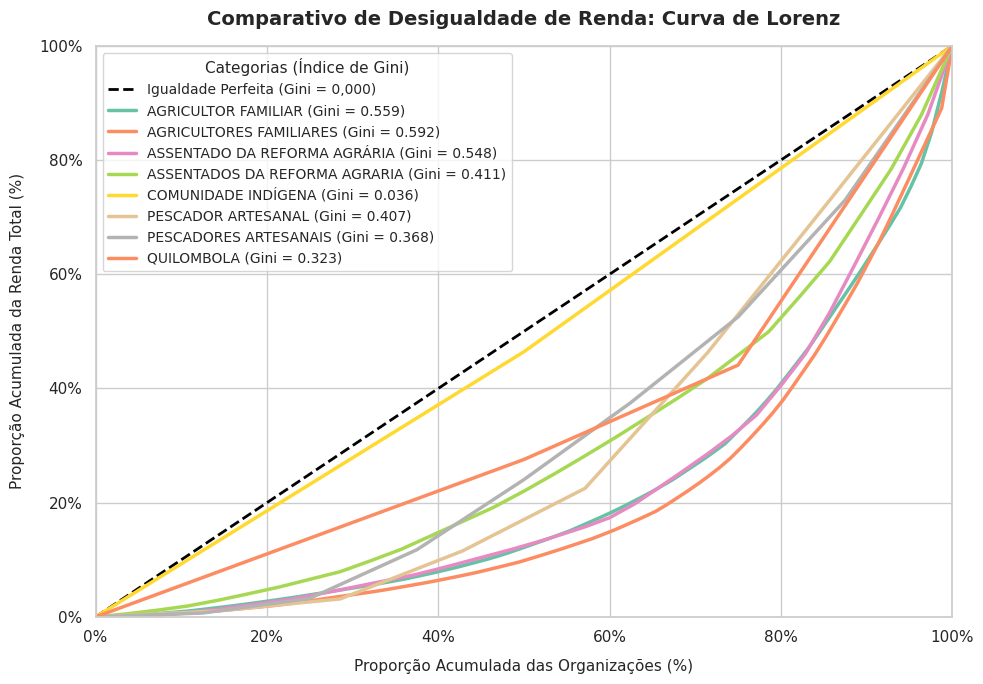


=== RANKING DE DESIGUALDADE (ÍNDICE DE GINI) ===


,Tipo de Organização,Índice de Gini
1,AGRICULTORES FAMILIARES,R$ 0.59
0,AGRICULTOR FAMILIAR,R$ 0.56
2,ASSENTADO DA REFORMA AGRÁRIA,R$ 0.55
3,ASSENTADOS DA REFORMA AGRARIA,R$ 0.41
5,PESCADOR ARTESANAL,R$ 0.41
6,PESCADORES ARTESANAIS,R$ 0.37
7,QUILOMBOLA,R$ 0.32
4,COMUNIDADE INDÍGENA,R$ 0.04


In [41]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

# Configuração de estilo
sns.set_theme(style="whitegrid", font="sans-serif")

# 1. Tratamento inicial dos dados
df_clean = renda_por_organizacao[
    (renda_por_organizacao['TIPO DE ORG'].notna())
    & (renda_por_organizacao['TIPO DE ORG'] != 'NAN')
    & (renda_por_organizacao['RENDA_TOTAL'] > 0)
].copy()


# Função para calcular a Curva de Lorenz e o Coeficiente de Gini
def calcular_lorenz_e_gini(valores):
  y = np.sort(np.asarray(valores))
  cum_y = np.cumsum(y)
  lorenz_y = cum_y / cum_y[-1]
  lorenz_y = np.insert(lorenz_y, 0, 0)
  lorenz_x = np.linspace(0, 1, len(lorenz_y))

  # Cálculo do Coeficiente de Gini
  n = len(y)
  gini = (2 * np.sum(np.arange(1, n + 1) * y) / (n * np.sum(y))) - (n + 1) / n
  return lorenz_x, lorenz_y, gini


# 2. Criar a figura
fig, ax = plt.subplots(figsize=(10, 7))

# Linha de Igualdade Perfeita (Linha Diagonal de Referência)
ax.plot(
    [0, 1],
    [0, 1],
    color='black',
    linestyle='--',
    linewidth=2,
    label='Igualdade Perfeita (Gini = 0,000)',
)

# Paleta de cores vibrantes
tipos = df_clean['TIPO DE ORG'].unique()
cores = sns.color_palette('Set2', len(tipos))

resumo_gini = []

# 3. Desenhar a curva para cada tipo de organização
for i, tipo in enumerate(tipos):
  grupo = df_clean[df_clean['TIPO DE ORG'] == tipo]['RENDA_TOTAL']

  if len(grupo) > 1:
    lx, ly, gini = calcular_lorenz_e_gini(grupo)
    resumo_gini.append({'Tipo de Organização': tipo, 'Índice de Gini': gini})

    ax.plot(
        lx,
        ly,
        label=f'{tipo} (Gini = {gini:.3f})',
        color=cores[i],
        linewidth=2.5,
    )

# 4. Formatação dos eixos em porcentagem (%)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Títulos e rótulos explicativos
ax.set_title(
    'Comparativo de Desigualdade de Renda: Curva de Lorenz',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
ax.set_xlabel(
    'Proporção Acumulada das Organizações (%)', fontsize=11, labelpad=10
)
ax.set_ylabel(
    'Proporção Acumulada da Renda Total (%)', fontsize=11, labelpad=10
)

# Ajuste da legenda
ax.legend(
    title='Categorias (Índice de Gini)',
    fontsize=10,
    title_fontsize=11,
    loc='upper left',
    frameon=True,
    facecolor='white',
)

plt.tight_layout()
plt.show()

# 5. Exibir a tabela ordenada com o ranking da desigualdade
df_gini = pd.DataFrame(resumo_gini).sort_values(
    by='Índice de Gini', ascending=False
)
print('\n=== RANKING DE DESIGUALDADE (ÍNDICE DE GINI) ===')
display(df_gini)

##Como interpretar o grafico:

    - A Linha Diagonal (Igualdade Perfeita):

        Se a renda fosse distribuída igualmente, 50% das organizações ficariam com exatamente 50% de toda a renda.

    - A Curvatura (Barriga) das Linhas:

        Linhas coladas na diagonal: Representam tipos de organização onde a distribuição de renda entre seus membros é bastante igualitária.

        Linhas muito curvadas para baixo: Revelam alta concentração de renda. Por exemplo, se a curva passa pelo ponto (80%, 10%), significa que 80% das organizações com menor faturamento somadas detêm apenas 10% da receita total daquela categoria.

    - Índice de Gini:

        Próximo de 0.0: Distribuição equitativa dos recursos.

        Próximo de 1.0: Concentração extrema da renda em pouquíssimas entidades.


### 📌 Como Funciona a Curva de Lorenz e o Cálculo do Índice de Gini

---

#### 1. A Curva de Lorenz: Passo a Passo

A **Curva de Lorenz** é a representação gráfica da distribuição acumulada de renda em uma população ou grupo de organizações.

* **Passo 1: Ordenação dos Dados**
  Ordene os dados da menor para a maior renda:
  $$y_1 \le y_2 \le \dots \le y_n$$

* **Passo 2: Eixo X — Proporção Acumulada da População ($p_i$)**
  Calcula-se a porcentagem acumulada de entidades (da menor para a maior renda):
  $$p_i = \frac{i}{n}$$

* **Passo 3: Eixo Y — Proporção Acumulada da Renda ($L_i$)**
  Calcula-se a fatia acumulada da renda total até a $i$-ésima posição:
  $$L_i = \frac{\sum_{j=1}^{i} y_j}{\sum_{j=1}^{n} y_j}$$

* **Passo 4: Plotagem**
  Plota-se o par ordenado $(p_i, L_i)$ partindo de $(0,0)$ até $(1,1)$. A linha de **Igualdade Perfeita** é a diagonal de 45° onde $p_i = L_i$.

---

#### 2. O Índice de Gini: Definição e Fórmulas

O **Índice de Gini** mede a área entre a linha de igualdade perfeita e a Curva de Lorenz.

* **Conceito Geométrico:**
  $$G = \frac{\text{Área } A}{\text{Área } A + \text{Área } B} = 2A = 1 - 2B$$
  * **Área A:** Região entre a reta diagonal e a Curva de Lorenz.
  * **Área B:** Região situada abaixo da Curva de Lorenz.

* **Fórmula Algébrica (para dados individuais pré-ordenados $y_1 \le y_2 \le \dots \le y_n$):**
  $$G = \frac{2 \sum_{i=1}^{n} i \cdot y_i}{n \sum_{i=1}^{n} y_i} - \frac{n + 1}{n}$$

---

#### 3. Exemplo Prático Numérico

Considere um grupo de **4 organizações** com renda total acumulada de **R$ 100,00**:
* Org A: R$ 10,00
* Org B: R$ 20,00
* Org C: R$ 30,00
* Org D: R$ 40,00

1. **População Acumulada ($p_i$):** 25%, 50%, 75%, 100%
2. **Renda Acumulada ($L_i$):**
   * Org A: $\frac{10}{100} = 10\%$
   * Org A + B: $\frac{10 + 20}{100} = 30\%$
   * Org A + B + C: $\frac{10 + 20 + 30}{100} = 60\%$
   * Org A + B + C + D: $\frac{100}{100} = 100\%$
3. **Cálculo do Gini:**
   $$\sum_{i=1}^{4} i \cdot y_i = (1 \cdot 10) + (2 \cdot 20) + (3 \cdot 30) + (4 \cdot 40) = 10 + 40 + 90 + 160 = 300$$
   $$G = \frac{2 \cdot 300}{4 \cdot 100} - \frac{4 + 1}{4} = \frac{600}{400} - 1,25 = 1,50 - 1,25 = 0,250$$

* **Resultado:** Índice de Gini de **0,250** (indica uma distribuição relativamente equitativa entre estas 4 organizações).

In [42]:
import numpy as np
import pandas as pd

# 1. Limpeza da base de dados (Aplica para todos os registros válidos)
df_clean = renda_por_organizacao[
    (renda_por_organizacao['TIPO DE ORG'].notna())
    & (renda_por_organizacao['TIPO DE ORG'] != 'NAN')
    & (renda_por_organizacao['RENDA_TOTAL'] > 0)
].copy()


# Função para calcular as áreas e o Índice de Gini de um vetor de dados
def calcular_metricas_lorenz(valores):
  y = np.sort(valores)
  n = len(y)
  if n < 2:
    return None

  cum_y = np.cumsum(y) / y.sum()
  ly = np.insert(cum_y, 0, 0)
  lx = np.linspace(0, 1, len(ly))

  # Integração numérica
  area_b = np.trapz(ly, lx)  # Área abaixo da curva
  area_a = 0.5 - area_b  # Área entre y=x e a Curva de Lorenz
  gini = 2 * area_a  # Coeficiente de Gini

  return {
      'Nº Orgs': n,
      'Renda Total (R$)': y.sum(),
      'Área A (y=x até Lorenz)': area_a,
      'Área B (Abaixo da Lorenz)': area_b,
      'Índice de Gini': gini,
  }


# 2. CÁLCULO PARA TODOS OS DADOS JUNTOS (TOTAL GERAL)
metricas_totais = calcular_metricas_lorenz(df_clean['RENDA_TOTAL'].values)
metricas_totais['Tipo de Organização'] = '🌐 TOTAL GERAL (Toda a Base)'

# 3. CÁLCULO POR CATEGORIA (TIPO DE ORG)
resultados_grupos = []
for tipo, grupo in df_clean.groupby('TIPO DE ORG'):
  m = calcular_metricas_lorenz(grupo['RENDA_TOTAL'].values)
  if m:
    m['Tipo de Organização'] = tipo
    resultados_grupos.append(m)

# Ordena os grupos por TAMANHO DA ÁREA A (Decrescente)
df_grupos = pd.DataFrame(resultados_grupos).sort_values(
    by='Área A (y=x até Lorenz)', ascending=False
)

# Unifica o Total Geral no topo + Categorias Ordenadas por Tamanho
df_geral = pd.DataFrame([metricas_totais])
df_final = pd.concat([df_geral, df_grupos], ignore_index=True)

# Reordenação de colunas
colunas = [
    'Tipo de Organização',
    'Nº Orgs',
    'Renda Total (R$)',
    'Área A (y=x até Lorenz)',
    'Área B (Abaixo da Lorenz)',
    'Índice de Gini',
]
df_final = df_final[colunas]

# 4. FORMATAÇÃO VISUAL PARA EXIBIÇÃO NO COLAB
df_exibicao = df_final.copy()
df_exibicao['Renda Total (R$)'] = df_exibicao['Renda Total (R$)'].apply(
    lambda x: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
)
df_exibicao['Área A (y=x até Lorenz)'] = df_exibicao[
    'Área A (y=x até Lorenz)'
].map('{:.6f}'.format)
df_exibicao['Área B (Abaixo da Lorenz)'] = df_exibicao[
    'Área B (Abaixo da Lorenz)'
].map('{:.6f}'.format)
df_exibicao['Índice de Gini'] = df_exibicao['Índice de Gini'].map(
    '{:.4f}'.format
)

display(df_exibicao)

/tmp/ipykernel_4355/1594392479.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_b = np.trapz(ly, lx)  # Área abaixo da curva
/tmp/ipykernel_4355/1594392479.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_b = np.trapz(ly, lx)  # Área abaixo da curva


,Tipo de Organização,Nº Orgs,Renda Total (R$),Área A (y=x até Lorenz),Área B (Abaixo da Lorenz),Índice de Gini
0,🌐 TOTAL GERAL (Toda a Base),250,"R$ 119.207.476,14",0.275637,0.224363,0.5513
1,AGRICULTORES FAMILIARES,81,"R$ 37.454.152,72",0.296092,0.203908,0.5922
2,AGRICULTOR FAMILIAR,83,"R$ 37.564.279,52",0.279579,0.220421,0.5592
3,ASSENTADO DA REFORMA AGRÁRIA,35,"R$ 17.416.129,43",0.274036,0.225964,0.5481
4,ASSENTADOS DA REFORMA AGRARIA,28,"R$ 14.829.144,30",0.205518,0.294482,0.4110
5,PESCADOR ARTESANAL,7,"R$ 2.374.303,56",0.203468,0.296532,0.4069
6,PESCADORES ARTESANAIS,8,"R$ 7.330.298,82",0.183985,0.316015,0.3680
7,QUILOMBOLA,4,"R$ 725.524,25",0.161394,0.338606,0.3228
8,COMUNIDADE INDÍGENA,2,"R$ 559.968,14",0.017846,0.482154,0.0357


### 📐 Cálculo da Área entre $y = x$ e a Curva de Lorenz (Todos os Dados)

* **Área A (y=x até Lorenz):** Mede diretamente a desigualdade do grupo. Quanto maior a área (mais próxima de 0,5), maior é a concentração de renda.
* **Tabela consolidada:** Apresenta o **TOTAL GERAL** (toda a base unificada) no topo e o ranking ordenado de cada categoria pelo tamanho da área.

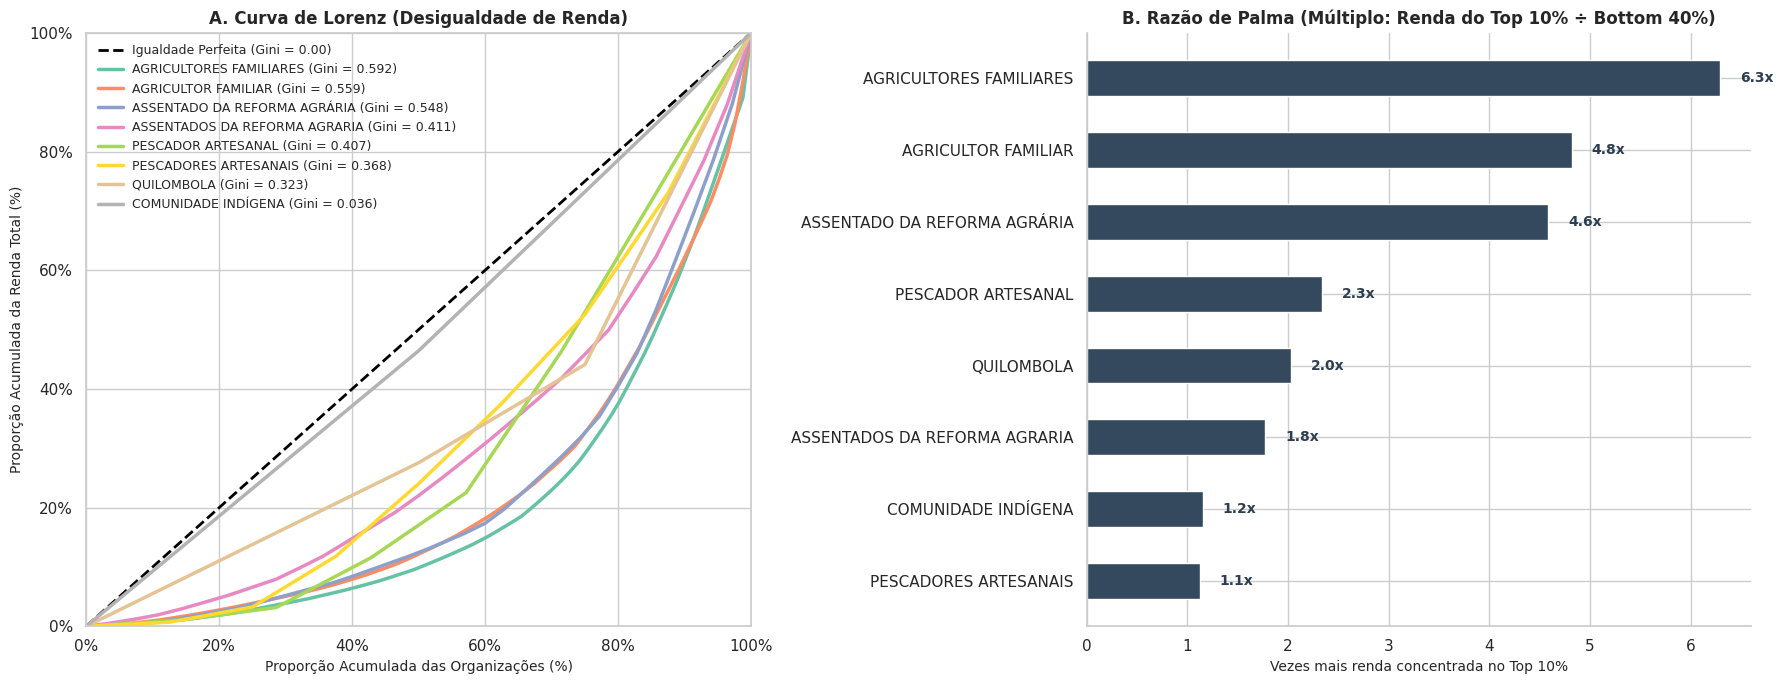


=== TABELA CONSOLIDADA DE DIAGNÓSTICO DE RENDA E DESIGUALDADE ===


,Tipo de Org.,Nº Orgs,Renda Total (R$),Share Global (%),Mediana (R$),Média (R$),Gini,% Top 10%,% Bottom 40%,Razão de Palma
1,AGRICULTORES FAMILIARES,81,"R$ 37.454.152,72",31.4%,"R$ 209.612,30","R$ 462.396,95",0.592,41.7%,6.6%,6.29x
0,AGRICULTOR FAMILIAR,83,"R$ 37.564.279,52",31.5%,"R$ 238.662,62","R$ 452.581,68",0.559,39.8%,8.3%,4.82x
2,ASSENTADO DA REFORMA AGRÁRIA,35,"R$ 17.416.129,43",14.6%,"R$ 214.998,32","R$ 497.603,70",0.548,38.5%,8.4%,4.58x
3,ASSENTADOS DA REFORMA AGRARIA,28,"R$ 14.829.144,30",12.4%,"R$ 436.753,90","R$ 529.612,30",0.411,29.7%,16.7%,1.78x
5,PESCADOR ARTESANAL,7,"R$ 2.374.303,56",2.0%,"R$ 260.079,60","R$ 339.186,22",0.407,27.0%,11.6%,2.33x
6,PESCADORES ARTESANAIS,8,"R$ 7.330.298,82",6.1%,"R$ 945.525,00","R$ 916.287,35",0.368,27.0%,24.0%,1.12x
7,QUILOMBOLA,4,"R$ 725.524,25",0.6%,"R$ 109.967,12","R$ 181.381,06",0.323,55.9%,27.6%,2.03x
4,COMUNIDADE INDÍGENA,2,"R$ 559.968,14",0.5%,"R$ 279.984,07","R$ 279.984,07",0.036,53.6%,46.4%,1.15x


In [43]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

# Estilo dos gráficos
sns.set_theme(style="whitegrid", font="sans-serif")

# 1. Tratamento da base
df_clean = renda_por_organizacao[
    (renda_por_organizacao['TIPO DE ORG'].notna())
    & (renda_por_organizacao['TIPO DE ORG'] != 'NAN')
    & (renda_por_organizacao['RENDA_TOTAL'] > 0)
].copy()


# 2. Função de Cálculo do Diagnóstico Avançado
def calcular_diagnostico_completo(df):
  resultados = []
  renda_global = df['RENDA_TOTAL'].sum()

  for tipo, grupo in df.groupby('TIPO DE ORG'):
    valores = np.sort(grupo['RENDA_TOTAL'].values)
    n = len(valores)
    if n < 2:
      continue

    renda_total_grupo = valores.sum()

    # Coeficiente de Gini
    gini = (2 * np.sum(np.arange(1, n + 1) * valores) / (n * renda_total_grupo)) - (
        n + 1
    ) / n

    # Recortes de Concentração (Top 10% e Bottom 40%)
    idx_bottom40 = int(np.ceil(n * 0.40))
    idx_top10 = int(np.floor(n * 0.90))

    renda_bottom40 = valores[:idx_bottom40].sum()
    renda_top10 = valores[idx_top10:].sum()

    pct_bottom40 = (renda_bottom40 / renda_total_grupo) * 100
    pct_top10 = (renda_top10 / renda_total_grupo) * 100

    # Razão de Palma (Renda do Top 10% / Renda do Bottom 40%)
    palma = (
        (renda_top10 / renda_bottom40) if renda_bottom40 > 0 else np.nan
    )

    resultados.append({
        'Tipo de Org.': tipo,
        'Nº Orgs': n,
        'Renda Total (R$)': renda_total_grupo,
        'Share Global (%)': (renda_total_grupo / renda_global) * 100,
        'Mediana (R$)': np.median(valores),
        'Média (R$)': np.mean(valores),
        'Gini': gini,
        '% Top 10%': pct_top10,
        '% Bottom 40%': pct_bottom40,
        'Razão de Palma': palma,
    })

  return pd.DataFrame(resultados).sort_values(by='Gini', ascending=False)


# Gerar tabela de indicadores
df_analise = calcular_diagnostico_completo(df_clean)

# ==============================================================================
# 3. GERAÇÃO DO PAINEL VISUAL (2 GRÁFICOS)
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))


# --- GRÁFICO 1: Curva de Lorenz ---
def lorenz_curve(valores):
  y = np.sort(valores)
  cum_y = np.cumsum(y) / y.sum()
  lorenz_y = np.insert(cum_y, 0, 0)
  lorenz_x = np.linspace(0, 1, len(lorenz_y))
  return lorenz_x, lorenz_y


ax1.plot(
    [0, 1],
    [0, 1],
    color='black',
    linestyle='--',
    linewidth=2,
    label='Igualdade Perfeita (Gini = 0.00)',
)

paleta = sns.color_palette('Set2', len(df_analise))

for i, row in df_analise.reset_index().iterrows():
  tipo = row['Tipo de Org.']
  valores = df_clean[df_clean['TIPO DE ORG'] == tipo]['RENDA_TOTAL'].values
  lx, ly = lorenz_curve(valores)
  ax1.plot(
      lx,
      ly,
      label=f"{tipo} (Gini = {row['Gini']:.3f})",
      color=paleta[i],
      linewidth=2.5,
  )

ax1.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.set_title(
    'A. Curva de Lorenz (Desigualdade de Renda)', fontsize=12, fontweight='bold'
)
ax1.set_xlabel('Proporção Acumulada das Organizações (%)', fontsize=10)
ax1.set_ylabel('Proporção Acumulada da Renda Total (%)', fontsize=10)
ax1.legend(loc='upper left', fontsize=9)

# --- GRÁFICO 2: Razão de Palma (Top 10% vs Bottom 40%) ---
df_sorted_palma = df_analise.sort_values(by='Razão de Palma', ascending=True)
bars = ax2.barh(
    df_sorted_palma['Tipo de Org.'],
    df_sorted_palma['Razão de Palma'],
    color='#34495e',
    height=0.5,
)

for bar in bars:
  w = bar.get_width()
  if not np.isnan(w):
    ax2.text(
      w + 0.2,
      bar.get_y() + bar.get_height() / 2,
      f'{w:.1f}x',
      va='center',
      fontsize=10,
      fontweight='bold',
      color='#2c3e50',
    )

ax2.set_title(
    'B. Razão de Palma (Múltiplo: Renda do Top 10% ÷ Bottom 40%)',
    fontsize=12,
    fontweight='bold',
)
ax2.set_xlabel('Vezes mais renda concentrada no Top 10%', fontsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ==============================================================================
# 4. EXIBIÇÃO DA TABELA CONSOLIDADA FORMATADA
# ==============================================================================
df_exibicao = df_analise.copy()
df_exibicao['Renda Total (R$)'] = df_exibicao['Renda Total (R$)'].apply(
    lambda x: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
)
df_exibicao['Mediana (R$)'] = df_exibicao['Mediana (R$)'].apply(
    lambda x: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
)
df_exibicao['Média (R$)'] = df_exibicao['Média (R$)'].apply(
    lambda x: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
)
df_exibicao['Share Global (%)'] = df_exibicao['Share Global (%)'].map(
    '{:.1f}%'.format
)
df_exibicao['Gini'] = df_exibicao['Gini'].map('{:.3f}'.format)
df_exibicao['% Top 10%'] = df_exibicao['% Top 10%'].map('{:.1f}%'.format)
df_exibicao['% Bottom 40%'] = df_exibicao['% Bottom 40%'].map('{:.1f}%'.format)
df_exibicao['Razão de Palma'] = df_exibicao['Razão de Palma'].map(
    '{:.2f}x'.format
)

print('\n=== TABELA CONSOLIDADA DE DIAGNÓSTICO DE RENDA E DESIGUALDADE ===')
display(df_exibicao)

### 📌 Interpretação e Impacto dos Indicadores na Análise

---

#### 1. Razão de Palma
$$\text{Razão de Palma} = \frac{\% \text{ da Renda do Top 10\%}}{\% \text{ da Renda do Bottom 40\%}}$$

* **O que agrega:** Converte a abstração da Curva de Lorenz em um argumento direto e de alto impacto executivo.
* **Aplicação na análise:** Permite pontuar com clareza no relatório: *"Na categoria X, o grupo dos 10% maiores detém 12,5 vezes mais renda do que os 40% menores somados."*

---

#### 2. Comparativo Mediana vs. Média
* **O que agrega:** Evidencia distorções causadas por *outliers* (entidades com faturamento atipicamente alto).
* **Aplicação na análise:** Quando a média supera expressivamente a mediana, prova-se quantitativamente que poucas organizações gigantes estão inflando a percepção de renda de todo o grupo.

---

#### 3. Representatividade de Mercado (*Share* Global %)
* **O que agrega:** Oferece contexto de escala e relevância econômica dentro do ecossistema analisado.
* **Aplicação na análise:** Evita conclusões precipitadas sobre segmentos que apresentam elevado Índice de Gini, mas cuja participação no faturamento total é insignificante.

## 7. Exportação do Resultado Final
Exporta os relatórios em formato CSV no Google Colab.

In [44]:
# Salvando as tabelas em CSV
renda_por_organizacao.to_csv('renda_por_organizacao_fornecedora.csv', index=False, encoding='utf-8-sig')
resumo_tipo.to_csv('resumo_renda_por_tipo_org.csv', index=False, encoding='utf-8-sig')

print('Arquivos exportados com sucesso:')
print('1. renda_por_organizacao_fornecedora.csv')
print('2. resumo_renda_por_tipo_org.csv')

Arquivos exportados com sucesso:
1. renda_por_organizacao_fornecedora.csv
2. resumo_renda_por_tipo_org.csv
